# Projet : Deep Learning for Crop Classification
# Partie 1 : Base Classification Model

In [40]:
import sys
print(sys.executable)

/usr/bin/python3


# **Chargement des fichiers CSV**

In [41]:
import pandas as pd

df_arkansas  = pd.read_csv("ARKANSAS_FULL.csv").copy()
df_california = pd.read_csv("CALIFORNIA_FULL.csv").copy()

# **Mapping de classes**

In [42]:
arkansas_mapping  = {5: "Soybeans", 1: "Corn", 3: "Rice", 2: "Cotton"}
california_mapping = {69: "Grapes", 3: "Rice", 36: "Alfalfa", 75: "Almonds", 204: "Pistachios"}

df_arkansas = df_arkansas.assign(
    class_name=df_arkansas["label"].map(arkansas_mapping).fillna("Others")
)
df_california = df_california.assign(
    class_name=df_california["label"].map(california_mapping).fillna("Others")
)

print(df_arkansas["class_name"].value_counts())
print(df_california["class_name"].value_counts())

class_name
Soybeans    4677
Rice        2423
Corn        1522
Cotton       762
Others       616
Name: count, dtype: int64
class_name
Others        3512
Grapes        2054
Rice          2037
Alfalfa        974
Almonds        783
Pistachios     640
Name: count, dtype: int64


# **Fonction de Split (80/20 train/val, reste = test)**

In [43]:
def make_split(df, n_per_class=300, train_ratio=0.8):
    train_parts, val_parts, used_indices = [], [], []

    for cls in sorted(df["class_name"].unique()):
        df_cls    = df[df["class_name"] == cls].sample(frac=1, random_state=42)
        n_sample  = min(len(df_cls), n_per_class)
        n_train   = int(n_sample * train_ratio)
        df_sample = df_cls.iloc[:n_sample]
        train_parts.append(df_sample.iloc[:n_train])
        val_parts.append(df_sample.iloc[n_train:])
        used_indices.extend(df_sample.index.tolist())

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df   = pd.concat(val_parts).reset_index(drop=True)
    test_df  = df.drop(index=used_indices).reset_index(drop=True)
    return train_df, val_df, test_df

train_ark, val_ark, test_ark = make_split(df_arkansas)
train_cal, val_cal, test_cal = make_split(df_california)

print(train_ark.shape, val_ark.shape, test_ark.shape)
print(train_cal.shape, val_cal.shape, test_cal.shape)

(1200, 370) (300, 370) (8500, 370)
(1440, 370) (360, 370) (8200, 370)


# **Imports**

In [44]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                              confusion_matrix, classification_report,
                              balanced_accuracy_score)
from sklearn.ensemble import RandomForestClassifier

In [45]:
BANDS  = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]
N_TIMES = 36
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

Device : cuda


# **Encodage des labels**

In [46]:
def encode_labels(train_df, val_df, test_df, label_col="class_name"):
    le = LabelEncoder()
    y_train = le.fit_transform(train_df[label_col])
    y_val   = le.transform(val_df[label_col])
    y_test  = le.transform(test_df[label_col])
    return y_train, y_val, y_test, le

# **Dataset PyTorch**

In [47]:
class CropTimeSeriesDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

# **Construction de X et du masque (valeurs manquantes)**

In [48]:
def build_mctnet_inputs(df, bands, n_times=36):
    X_list, mask_list = [], []

    for _, row in df.iterrows():
        sample, time_mask = [], []
        for t in range(n_times):
            values_t, valid_t = [], 0
            for b in bands:
                col = f"{b}_t{t}"
                val = row[col] if col in df.columns else np.nan
                val = pd.to_numeric(val, errors="coerce")
                if pd.notna(val):
                    valid_t = 1
                values_t.append(val)
            sample.append(values_t)
            time_mask.append(valid_t)

        sample = np.nan_to_num(np.array(sample, dtype=np.float32), nan=0.0)
        mask   = np.array(time_mask, dtype=np.float32)
        X_list.append(sample)
        mask_list.append(mask)

    return np.stack(X_list), np.stack(mask_list)

# **Positional Encoding sinusoïdale**

In [49]:
def sinusoidal_position_encoding(seq_len, dim, device):
    pe       = torch.zeros(seq_len, dim, device=device)
    position = torch.arange(0, seq_len, dtype=torch.float32, device=device).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, dim, 2, dtype=torch.float32, device=device) * (-math.log(10000.0) / dim)
    )
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

# **Module ALPE**

In [50]:
class ALPE(nn.Module):
    def __init__(self, d_model, kernel_size=3):
        super().__init__()
        self.conv    = nn.Conv1d(d_model, d_model, kernel_size=kernel_size, padding=kernel_size//2)
        self.eca     = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, time_mask):
        B, T, C = x.shape
        pe        = sinusoidal_position_encoding(T, C, x.device).unsqueeze(0).repeat(B, 1, 1)
        masked_pe = pe * time_mask.unsqueeze(-1)

        z = masked_pe.transpose(1, 2)
        z = self.conv(z)

        y = z.mean(dim=2, keepdim=True).transpose(1, 2)
        y = self.eca(y)
        y = self.sigmoid(y).transpose(1, 2)

        z = (z * y).transpose(1, 2)
        return z

# **Sous-module Transformer**

In [51]:
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, nhead=4, dropout=0.1, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        self.alpe     = ALPE(d_model) if use_alpe else None
        self.attn     = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1    = nn.LayerNorm(d_model)
        self.norm2    = nn.LayerNorm(d_model)
        self.ffn      = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x, time_mask):
        if self.use_alpe:
            x = x + self.alpe(x, time_mask)
        else:
            pe = sinusoidal_position_encoding(x.size(1), x.size(2), x.device)
            x  = x + pe.unsqueeze(0)

        kpm      = (time_mask == 0)
        attn_out, _ = self.attn(x, x, x, key_padding_mask=kpm)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

# **Sous-module CNN**

In [52]:
class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn1   = nn.BatchNorm1d(d_model)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn2   = nn.BatchNorm1d(d_model)
        self.relu  = nn.ReLU()

    def forward(self, x):
        residual = x
        z = x.transpose(1, 2)
        z = self.relu(self.bn1(self.conv1(z)))
        z = self.relu(self.bn2(self.conv2(z)))
        return z.transpose(1, 2) + residual

# **Bloc CTFusion**

In [53]:
class CTFusionBlock(nn.Module):
    def __init__(self, d_model, nhead=4, kernel_size=3, dropout=0.1, use_alpe=False):
        super().__init__()
        self.cnn   = CNNSubModule(d_model, kernel_size)
        self.trans = TransformerSubModule(d_model, nhead, dropout, use_alpe)
        self.fuse  = nn.Sequential(
            nn.Linear(d_model * 2, d_model), nn.GELU(), nn.LayerNorm(d_model)
        )
        self.pool  = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, time_mask):
        x_cnn   = self.cnn(x)
        x_trans = self.trans(x, time_mask)
        x_fused = self.fuse(torch.cat([x_cnn, x_trans], dim=-1))

        x_pooled    = self.pool(x_fused.transpose(1, 2)).transpose(1, 2)
        mask_pooled = (self.pool(time_mask.unsqueeze(1)).squeeze(1) > 0).float()
        return x_pooled, mask_pooled

# **Architecture MCTNet**

In [54]:
class MCTNet(nn.Module):
    def __init__(self, input_dim=10, num_classes=5, d_model=64,
                 n_stages=3, nhead=4, kernel_size=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.stages = nn.ModuleList([
            CTFusionBlock(d_model, nhead, kernel_size, dropout, use_alpe=(i == 0))
            for i in range(n_stages)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x, time_mask):
        x = self.input_proj(x)
        for stage in self.stages:
            x, time_mask = stage(x, time_mask)
        return self.classifier(x.max(dim=1).values)

# **Fonction d'entraînement**

In [55]:
def train_mctnet(model, train_loader, val_loader, device, epochs=40, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_b, mask_b, y_b in train_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b, mask_b), y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        y_true_v, y_pred_v = [], []
        with torch.no_grad():
            for X_b, mask_b, y_b in val_loader:
                preds = torch.argmax(model(X_b.to(device), mask_b.to(device)), dim=1)
                y_true_v.extend(y_b.numpy())
                y_pred_v.extend(preds.cpu().numpy())

        val_acc = accuracy_score(y_true_v, y_pred_v)
        print(f"Epoch {epoch+1:02d}/{epochs} | loss={train_loss/max(1,len(train_loader)):.4f} | val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = model.state_dict()

    if best_state:
        model.load_state_dict(best_state)
    print(f"\nMeilleure val accuracy : {best_val_acc:.4f}")
    return model

# **Fonction d'évaluation**

In [56]:
def evaluate_mctnet(model, loader, device, label_encoder, title="Evaluation"):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            X_b, mask_b, y_b = batch[0].to(device), batch[1].to(device), batch[2]
            preds = torch.argmax(model(X_b, mask_b), dim=1)
            y_true.extend(y_b.numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    oa    = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred, average="macro")
    kappa = cohen_kappa_score(y_true, y_pred)
    cm    = confusion_matrix(y_true, y_pred, normalize="true")

    print(f"\n===== {title} =====")
    print(f"OA    : {oa:.4f}")
    print(f"F1    : {f1:.4f}")
    print(f"Kappa : {kappa:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ticks = np.arange(len(label_encoder.classes_))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(label_encoder.classes_, rotation=30)
    ax.set_yticklabels(label_encoder.classes_)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    color="white" if v > 0.5 else "black")
    plt.tight_layout(); plt.show()
    return oa, f1, kappa, cm, y_true, y_pred

## **Arkansas — Préparation et Entraînement MCTNet**

In [57]:
y_train_ark, y_val_ark, y_test_ark, le_ark = encode_labels(train_ark, val_ark, test_ark)

X_train_ark, M_train_ark = build_mctnet_inputs(train_ark, BANDS, N_TIMES)
X_val_ark,   M_val_ark   = build_mctnet_inputs(val_ark,   BANDS, N_TIMES)
X_test_ark,  M_test_ark  = build_mctnet_inputs(test_ark,  BANDS, N_TIMES)

print("Arkansas X_train:", X_train_ark.shape, "M_train:", M_train_ark.shape)
print("Classes Arkansas:", list(le_ark.classes_))

Arkansas X_train: (1200, 36, 10) M_train: (1200, 36)
Classes Arkansas: ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans']


In [58]:
train_ds_ark = CropTimeSeriesDataset(X_train_ark, M_train_ark, y_train_ark)
val_ds_ark   = CropTimeSeriesDataset(X_val_ark,   M_val_ark,   y_val_ark)
test_ds_ark  = CropTimeSeriesDataset(X_test_ark,  M_test_ark,  y_test_ark)

train_loader_ark = DataLoader(train_ds_ark, batch_size=32, shuffle=True)
val_loader_ark   = DataLoader(val_ds_ark,   batch_size=32)
test_loader_ark  = DataLoader(test_ds_ark,  batch_size=32)

In [59]:
model_ark = MCTNet(
    input_dim=len(BANDS), num_classes=len(le_ark.classes_),
    d_model=64, n_stages=3, nhead=4, kernel_size=3, dropout=0.1
).to(DEVICE)

model_ark = train_mctnet(model_ark, train_loader_ark, val_loader_ark, DEVICE, epochs=200, lr=1e-3)

Epoch 01/200 | loss=1.2336 | val_acc=0.6067
Epoch 02/200 | loss=0.6989 | val_acc=0.7300
Epoch 03/200 | loss=0.4702 | val_acc=0.8067
Epoch 04/200 | loss=0.4339 | val_acc=0.7333
Epoch 05/200 | loss=0.3001 | val_acc=0.8333
Epoch 06/200 | loss=0.3481 | val_acc=0.8667
Epoch 07/200 | loss=0.2558 | val_acc=0.8267
Epoch 08/200 | loss=0.2349 | val_acc=0.8533
Epoch 09/200 | loss=0.2176 | val_acc=0.8733
Epoch 10/200 | loss=0.1560 | val_acc=0.8633
Epoch 11/200 | loss=0.1298 | val_acc=0.9100
Epoch 12/200 | loss=0.1525 | val_acc=0.8933
Epoch 13/200 | loss=0.1233 | val_acc=0.8833
Epoch 14/200 | loss=0.1781 | val_acc=0.8967
Epoch 15/200 | loss=0.1063 | val_acc=0.8700
Epoch 16/200 | loss=0.0759 | val_acc=0.8200
Epoch 17/200 | loss=0.0890 | val_acc=0.8800
Epoch 18/200 | loss=0.0796 | val_acc=0.8767
Epoch 19/200 | loss=0.1313 | val_acc=0.6400
Epoch 20/200 | loss=0.1022 | val_acc=0.9000
Epoch 21/200 | loss=0.0695 | val_acc=0.8900
Epoch 22/200 | loss=0.0519 | val_acc=0.8833
Epoch 23/200 | loss=0.0318 | val


===== Arkansas Test — MCTNet =====
OA    : 0.8412
F1    : 0.7770
Kappa : 0.7715
              precision    recall  f1-score   support

        Corn     0.7921    0.9010    0.8430      1222
      Cotton     0.5254    0.9610    0.6794       462
      Others     0.4225    0.9146    0.5780       316
        Rice     0.9397    0.9251    0.9324      2123
    Soybeans     0.9602    0.7658    0.8521      4377

    accuracy                         0.8412      8500
   macro avg     0.7280    0.8935    0.7770      8500
weighted avg     0.8873    0.8412    0.8512      8500



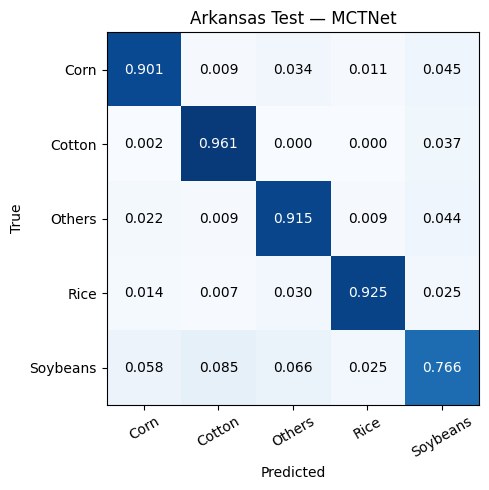

In [60]:
ark_test_oa, ark_test_f1, ark_test_kappa, ark_test_cm, _, _ = evaluate_mctnet(
    model_ark, test_loader_ark, DEVICE, le_ark, title="Arkansas Test — MCTNet"
)

## **California — Préparation et Entraînement MCTNet**

In [61]:
y_train_cal, y_val_cal, y_test_cal, le_cal = encode_labels(train_cal, val_cal, test_cal)

X_train_cal, M_train_cal = build_mctnet_inputs(train_cal, BANDS, N_TIMES)
X_val_cal,   M_val_cal   = build_mctnet_inputs(val_cal,   BANDS, N_TIMES)
X_test_cal,  M_test_cal  = build_mctnet_inputs(test_cal,  BANDS, N_TIMES)

print("California X_train:", X_train_cal.shape)
print("Classes California:", list(le_cal.classes_))

California X_train: (1440, 36, 10)
Classes California: ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']


In [62]:
train_ds_cal = CropTimeSeriesDataset(X_train_cal, M_train_cal, y_train_cal)
val_ds_cal   = CropTimeSeriesDataset(X_val_cal,   M_val_cal,   y_val_cal)
test_ds_cal  = CropTimeSeriesDataset(X_test_cal,  M_test_cal,  y_test_cal)

train_loader_cal = DataLoader(train_ds_cal, batch_size=32, shuffle=True)
val_loader_cal   = DataLoader(val_ds_cal,   batch_size=32)
test_loader_cal  = DataLoader(test_ds_cal,  batch_size=32)

In [63]:
model_cal = MCTNet(
    input_dim=len(BANDS), num_classes=len(le_cal.classes_),
    d_model=64, n_stages=3, nhead=4, kernel_size=3, dropout=0.1
).to(DEVICE)

model_cal = train_mctnet(model_cal, train_loader_cal, val_loader_cal, DEVICE, epochs=200, lr=1e-3)

Epoch 01/200 | loss=1.3781 | val_acc=0.4667
Epoch 02/200 | loss=0.9371 | val_acc=0.6611
Epoch 03/200 | loss=0.7688 | val_acc=0.5889
Epoch 04/200 | loss=0.6367 | val_acc=0.7333
Epoch 05/200 | loss=0.5764 | val_acc=0.7361
Epoch 06/200 | loss=0.5552 | val_acc=0.7000
Epoch 07/200 | loss=0.4843 | val_acc=0.7639
Epoch 08/200 | loss=0.4632 | val_acc=0.7778
Epoch 09/200 | loss=0.3992 | val_acc=0.7222
Epoch 10/200 | loss=0.3690 | val_acc=0.6722
Epoch 11/200 | loss=0.3416 | val_acc=0.8000
Epoch 12/200 | loss=0.3494 | val_acc=0.7667
Epoch 13/200 | loss=0.2884 | val_acc=0.7917
Epoch 14/200 | loss=0.2580 | val_acc=0.7472
Epoch 15/200 | loss=0.2138 | val_acc=0.7778
Epoch 16/200 | loss=0.1930 | val_acc=0.7472
Epoch 17/200 | loss=0.2349 | val_acc=0.7611
Epoch 18/200 | loss=0.2164 | val_acc=0.7806
Epoch 19/200 | loss=0.2107 | val_acc=0.8111
Epoch 20/200 | loss=0.1652 | val_acc=0.7944
Epoch 21/200 | loss=0.2314 | val_acc=0.7583
Epoch 22/200 | loss=0.1734 | val_acc=0.7417
Epoch 23/200 | loss=0.1342 | val


===== California Test — MCTNet =====
OA    : 0.8263
F1    : 0.7524
Kappa : 0.7729
              precision    recall  f1-score   support

     Alfalfa     0.6307    0.7804    0.6976       674
     Almonds     0.4321    0.6977    0.5337       483
      Grapes     0.8616    0.7383    0.7952      1754
      Others     0.9429    0.8334    0.8848      3212
  Pistachios     0.5164    0.8324    0.6374       340
        Rice     0.9776    0.9545    0.9659      1737

    accuracy                         0.8263      8200
   macro avg     0.7269    0.8061    0.7524      8200
weighted avg     0.8594    0.8263    0.8365      8200



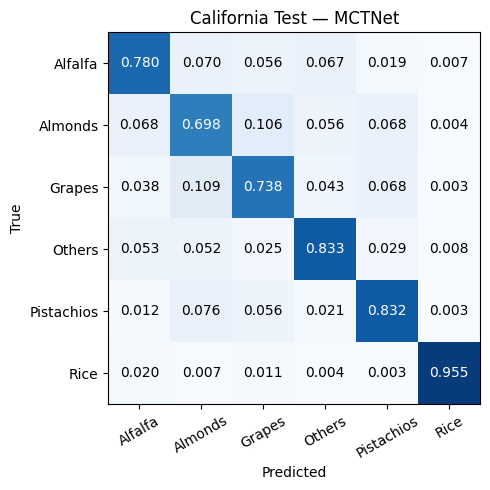

In [64]:
cal_test_oa, cal_test_f1, cal_test_kappa, cal_test_cm, _, _ = evaluate_mctnet(
    model_cal, test_loader_cal, DEVICE, le_cal, title="California Test — MCTNet"
)

## **Random Forest (baseline comparaison)**

In [65]:
def train_evaluate_rf(train_df, val_df, test_df, region_name):
    drop_cols = ["label", "class_name"]
    X_tr = train_df.drop(columns=drop_cols, errors="ignore")
    y_tr = train_df["class_name"]
    X_va = val_df.drop(columns=drop_cols, errors="ignore")
    y_va = val_df["class_name"]
    X_te = test_df.drop(columns=drop_cols, errors="ignore")
    y_te = test_df["class_name"]

    common = X_tr.columns.intersection(X_va.columns).intersection(X_te.columns)
    X_tr = X_tr[common].apply(pd.to_numeric, errors="coerce").fillna(0)
    X_va = X_va[common].apply(pd.to_numeric, errors="coerce").fillna(0)
    X_te = X_te[common].apply(pd.to_numeric, errors="coerce").fillna(0)

    clf = RandomForestClassifier(n_estimators=500, max_depth=20,
                                  random_state=42, n_jobs=-1,
                                  class_weight="balanced_subsample")
    clf.fit(X_tr, y_tr)

    for name, X, y in [("Train", X_tr, y_tr), ("Val", X_va, y_va), ("Test", X_te, y_te)]:
        p = clf.predict(X)
        print(f"[{region_name}] {name} — OA={accuracy_score(y,p):.4f} "              f"Kappa={cohen_kappa_score(y,p):.4f} "              f"F1={f1_score(y,p,average='macro',zero_division=0):.4f}")
    return clf

clf_ark = train_evaluate_rf(train_ark, val_ark, test_ark, "Arkansas")
clf_cal = train_evaluate_rf(train_cal, val_cal, test_cal, "California")

[Arkansas] Train — OA=1.0000 Kappa=1.0000 F1=1.0000
[Arkansas] Val — OA=0.8800 Kappa=0.8500 F1=0.8788
[Arkansas] Test — OA=0.8515 Kappa=0.7826 F1=0.7932
[California] Train — OA=1.0000 Kappa=1.0000 F1=1.0000
[California] Val — OA=0.7889 Kappa=0.7467 F1=0.7888
[California] Test — OA=0.8263 Kappa=0.7715 F1=0.7481


## **Calcul NDVI et visualisation**

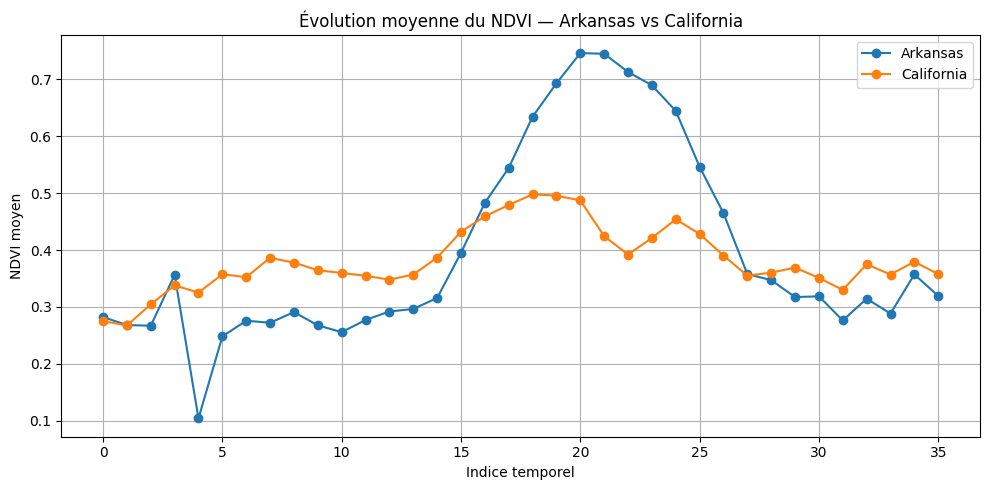

In [66]:
for t in range(36):
    for df in [df_arkansas, df_california]:
        denom = df[f"B8_t{t}"] + df[f"B4_t{t}"]
        df[f"NDVI_t{t}"] = np.where(denom != 0,
            (df[f"B8_t{t}"] - df[f"B4_t{t}"]) / denom, np.nan)

mean_ndvi_ark = [df_arkansas[f"NDVI_t{t}"].mean() for t in range(36)]
mean_ndvi_cal = [df_california[f"NDVI_t{t}"].mean() for t in range(36)]

plt.figure(figsize=(10, 5))
plt.plot(range(36), mean_ndvi_ark, marker='o', label="Arkansas")
plt.plot(range(36), mean_ndvi_cal, marker='o', label="California")
plt.xlabel("Indice temporel"); plt.ylabel("NDVI moyen")
plt.title("Évolution moyenne du NDVI — Arkansas vs California")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

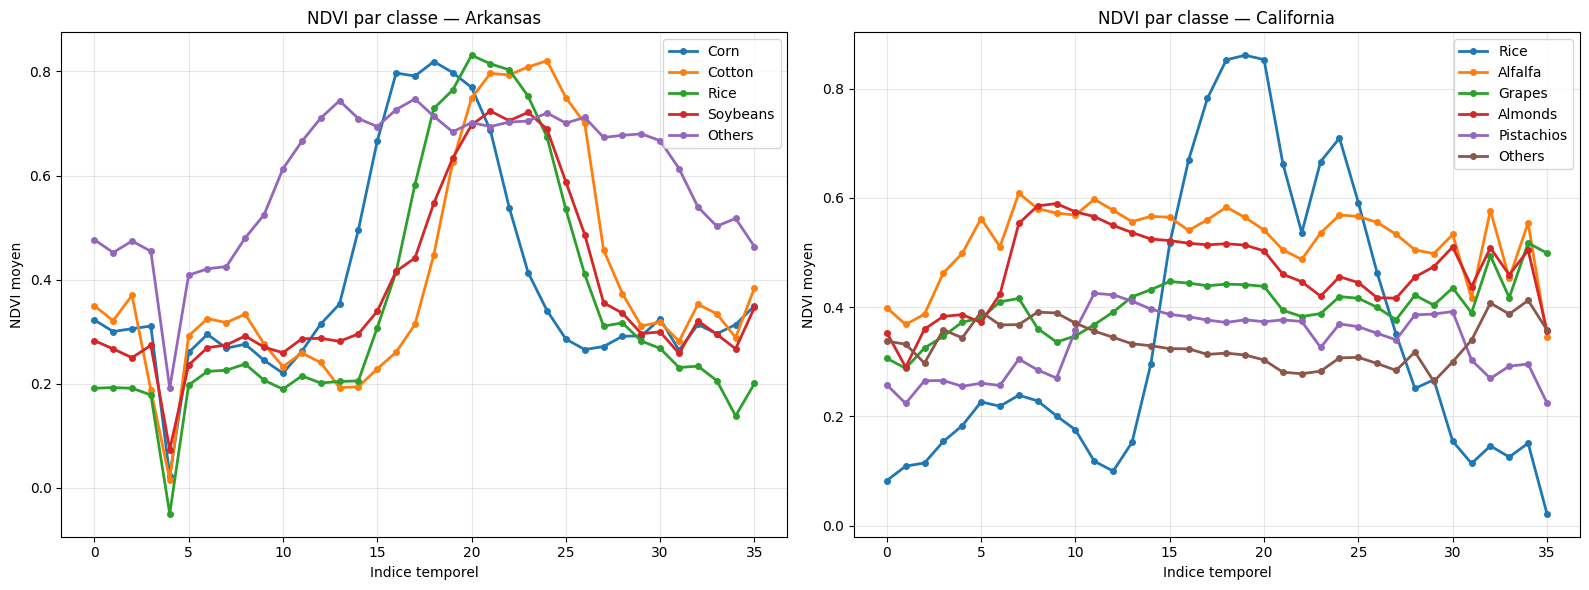

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in [(axes[0], df_arkansas, "Arkansas"), (axes[1], df_california, "California")]:
    classes_info = df[["label","class_name"]].drop_duplicates().sort_values("label")
    for _, row in classes_info.iterrows():
        sub   = df[df["label"] == row["label"]]
        curve = [sub[f"NDVI_t{t}"].mean() for t in range(36)]
        ax.plot(range(36), curve, marker='o', linewidth=2, markersize=4,
                label=f"{row['class_name']}")
    ax.set_title(f"NDVI par classe — {title}")
    ax.set_xlabel("Indice temporel"); ax.set_ylabel("NDVI moyen")
    ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
# Partie 2 : Intégration des Covariables Environnementales

In [68]:
## 2.1 — Détection automatique des colonnes covariables dans les CSV
# Les colonnes Sentinel-2 suivent le pattern BX_tY.
# Toutes les autres colonnes (hors label/class_name) sont des covariables.

s2_pattern = [f"{b}_t{t}" for b in BANDS for t in range(N_TIMES)]
ndvi_pattern = [f"NDVI_t{t}" for t in range(N_TIMES)]

exclude_always = ["label", "class_name"] + s2_pattern + ndvi_pattern

all_cov_cols_ark = [c for c in df_arkansas.columns
                    if c not in exclude_always and not c.startswith("NDVI")]
all_cov_cols_cal = [c for c in df_california.columns
                    if c not in exclude_always and not c.startswith("NDVI")]

print("Covariables détectées — Arkansas  :", all_cov_cols_ark)
print("Covariables détectées — California:", all_cov_cols_cal)

Covariables détectées — Arkansas  : ['temp_mean_c', 'precip_mm', 'dewpoint_c', 'soil_ph', 'soil_oc', 'soil_texture', 'elevation_m', 'landform_class']
Covariables détectées — California: ['temp_mean_c', 'precip_mm', 'dewpoint_c', 'soil_ph', 'soil_oc', 'soil_texture', 'elevation_m', 'landform_class']


In [69]:
## 2.2 — Définition des groupes covariables pour l'ablation
# À adapter selon les colonnes réelles présentes dans vos CSV.
# Les noms ci-dessous correspondent aux exports GEE fournis.

COV_CLIMATE = [c for c in all_cov_cols_ark
               if any(k in c.lower() for k in ["temp","prec","dew","wind","rad","hum","era"])]
COV_SOIL    = [c for c in all_cov_cols_ark
               if any(k in c.lower() for k in ["soil","ph","oc","sand","clay","silt","bulk","cec"])]
COV_TOPO    = [c for c in all_cov_cols_ark
               if any(k in c.lower() for k in ["elev","dem","slope","aspect","landform","topo"])]

# Fallback : si la détection automatique ne trouve rien, on partage équitablement
if not COV_CLIMATE and not COV_SOIL and not COV_TOPO and all_cov_cols_ark:
    n = len(all_cov_cols_ark)
    COV_CLIMATE = all_cov_cols_ark[:n//3]
    COV_SOIL    = all_cov_cols_ark[n//3: 2*n//3]
    COV_TOPO    = all_cov_cols_ark[2*n//3:]

COV_ALL = list(dict.fromkeys(COV_CLIMATE + COV_SOIL + COV_TOPO))

# Configurations de l'étude d'ablation (identiques pour les deux régions)
COV_CONFIGS = {
    "S2 Only"     : [],
    "S2 + Climate": COV_CLIMATE,
    "S2 + Soil"   : COV_SOIL,
    "S2 + Topo"   : COV_TOPO,
    "S2 + All"    : COV_ALL,
}

print("Configurations :")
for k, v in COV_CONFIGS.items():
    print(f"  {k:20s} -> {v}")

Configurations :
  S2 Only              -> []
  S2 + Climate         -> ['temp_mean_c', 'precip_mm', 'dewpoint_c']
  S2 + Soil            -> ['soil_ph', 'soil_oc', 'soil_texture']
  S2 + Topo            -> ['elevation_m', 'landform_class']
  S2 + All             -> ['temp_mean_c', 'precip_mm', 'dewpoint_c', 'soil_ph', 'soil_oc', 'soil_texture', 'elevation_m', 'landform_class']


## 2.3 — Dataset PyTorch étendu avec covariables

In [70]:
class CropDatasetWithCov(Dataset):
    """Dataset qui accepte les covariables statiques en plus de la série temporelle."""
    def __init__(self, X_s2, mask, X_cov, y):
        self.X_s2  = torch.tensor(X_s2,  dtype=torch.float32)
        self.mask  = torch.tensor(mask,  dtype=torch.float32)
        self.X_cov = torch.tensor(X_cov, dtype=torch.float32)
        self.y     = torch.tensor(y,     dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_s2[idx], self.mask[idx], self.X_cov[idx], self.y[idx]

## 2.4 — MCTNet étendu pour accepter les covariables

In [71]:
class MCTNetWithCov(nn.Module):
    """MCTNet de la Partie 1 + tête statique pour les covariables.
    Si n_cov == 0, le modèle est identique au MCTNet de base."""
    def __init__(self, input_dim=10, n_cov=0, num_classes=5,
                 d_model=64, n_stages=3, nhead=4, kernel_size=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.stages = nn.ModuleList([
            CTFusionBlock(d_model, nhead, kernel_size, dropout, use_alpe=(i == 0))
            for i in range(n_stages)
        ])

        # Tête pour les covariables (ignorée si n_cov == 0)
        self.n_cov = n_cov
        if n_cov > 0:
            self.cov_head = nn.Sequential(
                nn.Linear(n_cov, 32), nn.ReLU(), nn.Dropout(dropout)
            )
            fusion_dim = d_model + 32
        else:
            self.cov_head = None
            fusion_dim    = d_model

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, d_model), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x, time_mask, x_cov=None):
        x = self.input_proj(x)
        for stage in self.stages:
            x, time_mask = stage(x, time_mask)
        feat = x.max(dim=1).values                         # [B, d_model]

        if self.cov_head is not None and x_cov is not None:
            feat = torch.cat([feat, self.cov_head(x_cov)], dim=1)

        return self.classifier(feat)

## 2.5 — Fonctions utilitaires pour l'ablation

In [72]:
def build_cov_arrays(train_df, val_df, test_df, cov_cols):
    """Normalise les covariables avec un StandardScaler fitté sur train.
    C'est la règle fondamentale pour éviter le data leakage"""
    if not cov_cols:
        empty = lambda df: np.zeros((len(df), 0), dtype=np.float32)
        return empty(train_df), empty(val_df), empty(test_df)
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train_df[cov_cols].fillna(0).values).astype(np.float32)
    X_val   = scaler.transform(val_df[cov_cols].fillna(0).values).astype(np.float32)
    X_test  = scaler.transform(test_df[cov_cols].fillna(0).values).astype(np.float32)
    return X_train, X_val, X_test


def train_ablation_config(X_s2_tr, M_tr, C_tr, y_tr,
                           X_s2_va, M_va, C_va, y_va,
                           X_s2_te, M_te, C_te, y_te,
                           n_classes, le, device, epochs=200):
    """Entraîne un MCTNetWithCov pour une configuration donnée et retourne les métriques."""
    n_cov = C_tr.shape[1]

    ds_tr = CropDatasetWithCov(X_s2_tr, M_tr, C_tr, y_tr)
    ds_va = CropDatasetWithCov(X_s2_va, M_va, C_va, y_va)
    ds_te = CropDatasetWithCov(X_s2_te, M_te, C_te, y_te)

    ldr_tr = DataLoader(ds_tr, batch_size=32, shuffle=True)
    ldr_va = DataLoader(ds_va, batch_size=32)
    ldr_te = DataLoader(ds_te, batch_size=32)

    model = MCTNetWithCov(
        input_dim=10, n_cov=n_cov, num_classes=n_classes,
        d_model=64, n_stages=3, nhead=4, kernel_size=3, dropout=0.1
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        for X_b, M_b, C_b, y_b in ldr_tr:
            X_b, M_b, C_b, y_b = X_b.to(device), M_b.to(device), C_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b, M_b, C_b), y_b)
            loss.backward(); optimizer.step()

        model.eval()
        y_tv, y_pv = [], []
        with torch.no_grad():
            for X_b, M_b, C_b, y_b in ldr_va:
                p = torch.argmax(model(X_b.to(device), M_b.to(device), C_b.to(device)), 1)
                y_tv.extend(y_b.numpy()); y_pv.extend(p.cpu().numpy())
        val_acc = accuracy_score(y_tv, y_pv)
        if val_acc > best_val_acc:
            best_val_acc = val_acc; best_state = model.state_dict()

    model.load_state_dict(best_state)
    model.eval()
    y_tt, y_pt = [], []
    with torch.no_grad():
        for X_b, M_b, C_b, y_b in ldr_te:
            p = torch.argmax(model(X_b.to(device), M_b.to(device), C_b.to(device)), 1)
            y_tt.extend(y_b.numpy()); y_pt.extend(p.cpu().numpy())

    y_tt, y_pt = np.array(y_tt), np.array(y_pt)
    return {
        "OA"   : round(accuracy_score(y_tt, y_pt), 4),
        "F1"   : round(f1_score(y_tt, y_pt, average="macro"), 4),
        "Kappa": round(cohen_kappa_score(y_tt, y_pt), 4),
    }

## 2.6 — Boucle d'ablation — Arkansas

In [73]:
# Préparer les features S2 une seule fois pour Arkansas
X_s2_tr_ark, M_tr_ark = build_mctnet_inputs(train_ark, BANDS, N_TIMES)
X_s2_va_ark, M_va_ark = build_mctnet_inputs(val_ark,   BANDS, N_TIMES)
X_s2_te_ark, M_te_ark = build_mctnet_inputs(test_ark,  BANDS, N_TIMES)

y_tr_ark_enc, y_va_ark_enc, y_te_ark_enc, le_ark_abl = encode_labels(train_ark, val_ark, test_ark)
n_classes_ark = len(le_ark_abl.classes_)

results_ark = {}

for config_name, cov_cols in COV_CONFIGS.items():
    print(f"\n>>> [Arkansas] Configuration : {config_name}  ({len(cov_cols)} covariables)")

    C_tr, C_va, C_te = build_cov_arrays(train_ark, val_ark, test_ark, cov_cols)

    res = train_ablation_config(
        X_s2_tr_ark, M_tr_ark, C_tr, y_tr_ark_enc,
        X_s2_va_ark, M_va_ark, C_va, y_va_ark_enc,
        X_s2_te_ark, M_te_ark, C_te, y_te_ark_enc,
        n_classes=n_classes_ark, le=le_ark_abl, device=DEVICE, epochs=200
    )
    results_ark[config_name] = res
    print(f"    OA={res['OA']:.4f} | F1={res['F1']:.4f} | Kappa={res['Kappa']:.4f}")

print("\n=== Ablation Arkansas terminée ===")
p2_ark = results_ark["S2 + All"]


>>> [Arkansas] Configuration : S2 Only  (0 covariables)
    OA=0.8500 | F1=0.7898 | Kappa=0.7822

>>> [Arkansas] Configuration : S2 + Climate  (3 covariables)
    OA=0.7006 | F1=0.6584 | Kappa=0.6048

>>> [Arkansas] Configuration : S2 + Soil  (3 covariables)
    OA=0.8576 | F1=0.8161 | Kappa=0.7913

>>> [Arkansas] Configuration : S2 + Topo  (2 covariables)
    OA=0.8364 | F1=0.7765 | Kappa=0.7660

>>> [Arkansas] Configuration : S2 + All  (8 covariables)
    OA=0.8629 | F1=0.8112 | Kappa=0.7997

=== Ablation Arkansas terminée ===


## 2.7 — Boucle d'ablation — California

In [74]:
# Préparer les features S2 une seule fois pour California
X_s2_tr_cal, M_tr_cal = build_mctnet_inputs(train_cal, BANDS, N_TIMES)
X_s2_va_cal, M_va_cal = build_mctnet_inputs(val_cal,   BANDS, N_TIMES)
X_s2_te_cal, M_te_cal = build_mctnet_inputs(test_cal,  BANDS, N_TIMES)

y_tr_cal_enc, y_va_cal_enc, y_te_cal_enc, le_cal_abl = encode_labels(train_cal, val_cal, test_cal)
n_classes_cal = len(le_cal_abl.classes_)

# Recalculer COV_CONFIGS pour California (même logique, colonnes éventuellement différentes)
COV_CLIMATE_CAL = [c for c in all_cov_cols_cal
                   if any(k in c.lower() for k in ["temp","prec","dew","wind","rad","hum","era"])]
COV_SOIL_CAL    = [c for c in all_cov_cols_cal
                   if any(k in c.lower() for k in ["soil","ph","oc","sand","clay","silt","bulk","cec"])]
COV_TOPO_CAL    = [c for c in all_cov_cols_cal
                   if any(k in c.lower() for k in ["elev","dem","slope","aspect","landform","topo"])]

if not COV_CLIMATE_CAL and not COV_SOIL_CAL and not COV_TOPO_CAL and all_cov_cols_cal:
    n = len(all_cov_cols_cal)
    COV_CLIMATE_CAL = all_cov_cols_cal[:n//3]
    COV_SOIL_CAL    = all_cov_cols_cal[n//3: 2*n//3]
    COV_TOPO_CAL    = all_cov_cols_cal[2*n//3:]

COV_ALL_CAL = list(dict.fromkeys(COV_CLIMATE_CAL + COV_SOIL_CAL + COV_TOPO_CAL))

COV_CONFIGS_CAL = {
    "S2 Only"     : [],
    "S2 + Climate": COV_CLIMATE_CAL,
    "S2 + Soil"   : COV_SOIL_CAL,
    "S2 + Topo"   : COV_TOPO_CAL,
    "S2 + All"    : COV_ALL_CAL,
}

results_cal = {}

for config_name, cov_cols in COV_CONFIGS_CAL.items():
    print(f"\n>>> [California] Configuration : {config_name}  ({len(cov_cols)} covariables)")

    C_tr, C_va, C_te = build_cov_arrays(train_cal, val_cal, test_cal, cov_cols)

    res = train_ablation_config(
        X_s2_tr_cal, M_tr_cal, C_tr, y_tr_cal_enc,
        X_s2_va_cal, M_va_cal, C_va, y_va_cal_enc,
        X_s2_te_cal, M_te_cal, C_te, y_te_cal_enc,
        n_classes=n_classes_cal, le=le_cal_abl, device=DEVICE, epochs=200
    )
    results_cal[config_name] = res
    print(f"    OA={res['OA']:.4f} | F1={res['F1']:.4f} | Kappa={res['Kappa']:.4f}")

print("\n=== Ablation California terminée ===")
p2_cal = results_cal["S2 + All"]


>>> [California] Configuration : S2 Only  (0 covariables)
    OA=0.8401 | F1=0.7680 | Kappa=0.7897

>>> [California] Configuration : S2 + Climate  (3 covariables)
    OA=0.8555 | F1=0.7930 | Kappa=0.8096

>>> [California] Configuration : S2 + Soil  (3 covariables)
    OA=0.8428 | F1=0.7717 | Kappa=0.7938

>>> [California] Configuration : S2 + Topo  (2 covariables)
    OA=0.8321 | F1=0.7627 | Kappa=0.7801

>>> [California] Configuration : S2 + All  (8 covariables)
    OA=0.8484 | F1=0.7787 | Kappa=0.8010

=== Ablation California terminée ===


## 2.8 — Tableau de résultats comparatif

In [75]:
df_abl_ark = pd.DataFrame(results_ark).T.rename_axis("Configuration")
df_abl_cal = pd.DataFrame(results_cal).T.rename_axis("Configuration")

print("\n========== Ablation Study — Arkansas ==========")
print(df_abl_ark.to_string())

print("\n========== Ablation Study — California ==========")
print(df_abl_cal.to_string())


========== Ablation Study — Arkansas ==========
                   OA      F1   Kappa
Configuration                        
S2 Only        0.8500  0.7898  0.7822
S2 + Climate   0.7006  0.6584  0.6048
S2 + Soil      0.8576  0.8161  0.7913
S2 + Topo      0.8364  0.7765  0.7660
S2 + All       0.8629  0.8112  0.7997

========== Ablation Study — California ==========
                   OA      F1   Kappa
Configuration                        
S2 Only        0.8401  0.7680  0.7897
S2 + Climate   0.8555  0.7930  0.8096
S2 + Soil      0.8428  0.7717  0.7938
S2 + Topo      0.8321  0.7627  0.7801
S2 + All       0.8484  0.7787  0.8010


## 2.9 — Visualisation de l'étude d'ablation

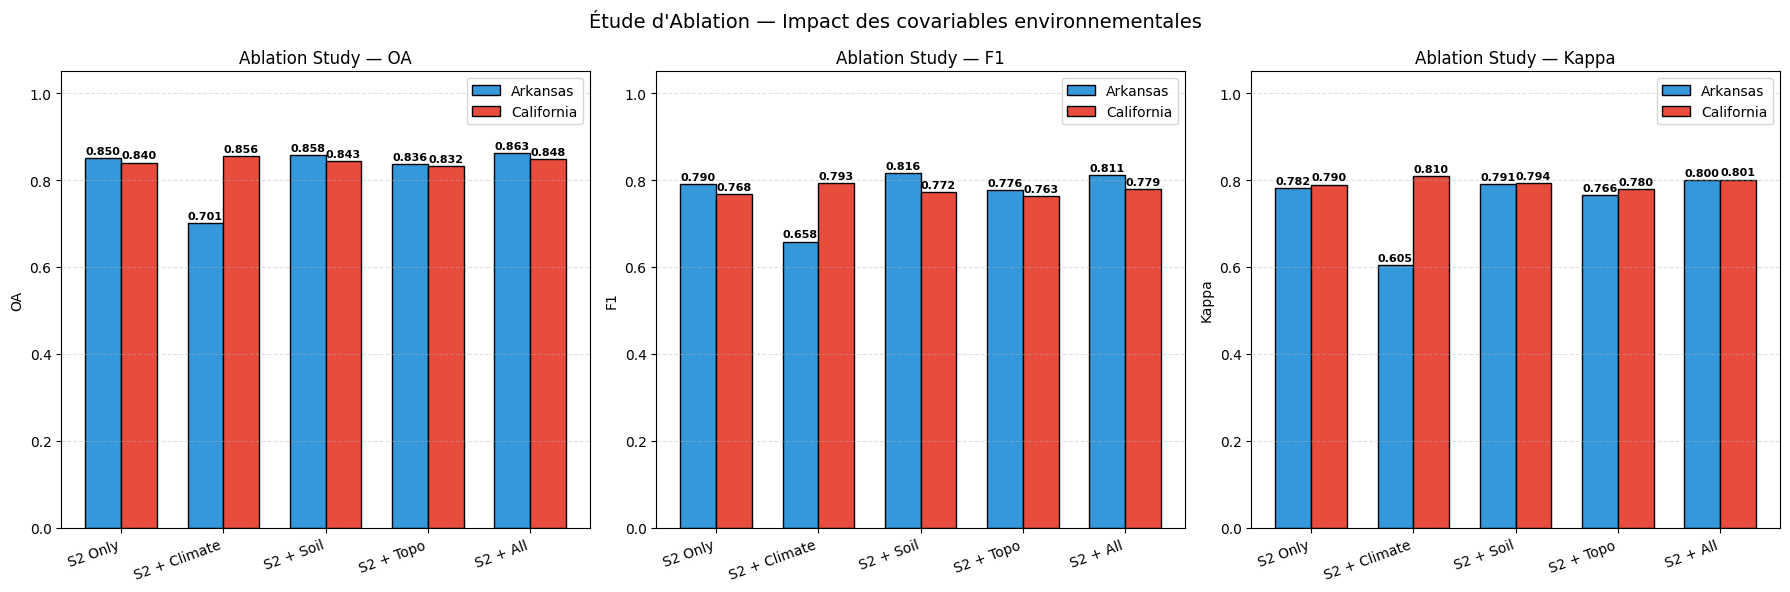

Figure sauvegardée : ablation_study.png


In [76]:
labels    = list(COV_CONFIGS.keys())
metrics   = ["OA", "F1", "Kappa"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, metrics):
    ark_vals = [results_ark[l][metric] for l in labels]
    cal_vals = [results_cal[l][metric] for l in labels]

    x     = np.arange(len(labels))
    width = 0.35

    r1 = ax.bar(x - width/2, ark_vals, width, label="Arkansas",  color="#3498db", edgecolor="black")
    r2 = ax.bar(x + width/2, cal_vals, width, label="California", color="#e74c3c", edgecolor="black")

    ax.set_title(f"Ablation Study — {metric}")
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for rect, val in [(r, v) for r, v in zip(list(r1)+list(r2), ark_vals+cal_vals)]:
        ax.annotate(f"{val:.3f}",
                    xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Étude d'Ablation — Impact des covariables environnementales", fontsize=14)
plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : ablation_study.png")

# Partie 3 — HybridCropNet (SSL Pretraining + Supervised Fine-tuning)

Architecture proposée combinant **apprentissage non-supervisé** (Masked Autoencoder) et **apprentissage supervisé** (classification).

**Stratégie en 2 étapes :**

1. **Pré-entraînement SSL (Self-Supervised Learning)** — Masked Autoencoder
   - Utilise les **10 000 échantillons** disponibles (train + val + test)
   - Aucun label utilisé (uniquement les features)
   - On masque ~40% des time-steps et on demande au modèle de les reconstruire
   - Permet à l'encodeur d'apprendre les patterns phénologiques généraux

2. **Fine-tuning supervisé** sur le train set labellisé
   - Cross-Entropy → Focal Loss pondérée + label smoothing
   - Mixup augmentation pour time-series
   - EMA des poids (decay=0.999)
   - Cosine Annealing avec Warm Restarts
   - Early stopping (patience=30)

**Améliorations architecturales vs v3 :**
- **Multi-scale convolutions** (kernels 3/5/7) → capture la phénologie multi-échelle
- **BiGRU + Transformer entrelacés** → biais inductifs complémentaires
- **Cross-Attention** pour la fusion des covariables (au lieu du gate simple)
- **Stochastic Depth** dans les blocs Transformer
- **Squeeze-Excitation** pour l'attention canal
- **Indices végétation enrichis** : NDVI + NDWI + SAVI + GNDVI (input_dim=14)

La comparaison se fait avec le meilleur modèle de Partie 2 : `S2 + All`.


Device : cuda

Sanitisation Arkansas :
  NaN remplacés : 0 | Inf remplacés : 0
Sanitisation California :
  NaN remplacés : 0 | Inf remplacés : 0

Après indices : (10000, 516) (10000, 516)

HybridCropNet — Arkansas
Classes : ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans']

Construction inputs S2 + NDVI + NDWI + SAVI + GNDVI ...
Shapes : (1200, 36, 14) (300, 36, 14) (8500, 36, 14) (10000, 36, 14)

Diagnostic finitude :
  [OK] X_tr : finite, shape=(1200, 36, 14), min=-7.427, max=10.000
  [OK] X_va : finite, shape=(300, 36, 14), min=-7.427, max=10.000
  [OK] X_te : finite, shape=(8500, 36, 14), min=-7.427, max=10.000
  [OK] X_full : finite, shape=(10000, 36, 14), min=-7.427, max=10.000

Construction covariables (climat + topo + GPS) ...
Covariables : ['temp_mean_c', 'precip_mm', 'dewpoint_c', 'elevation_m', 'landform_class', 'lon', 'lat']
Shape covariables : (1200, 7)
  [OK] C_tr : finite, shape=(1200, 7), min=-3.175, max=7.404
  [OK] C_va : finite, shape=(300, 7), min=-3.224, max=5.613
 

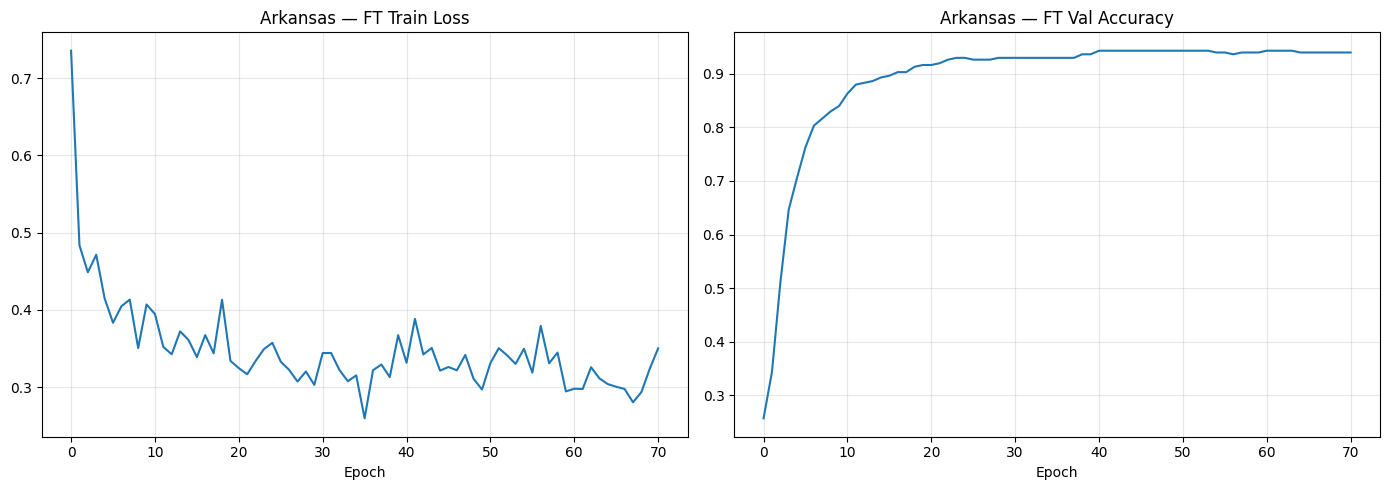


===== Arkansas — HybridCropNet (Test) =====
OA    : 0.9000
F1    : 0.8499
Kappa : 0.8512
              precision    recall  f1-score   support

        Corn     0.8681    0.9157    0.8913      1222
      Cotton     0.6501    0.9654    0.7770       462
      Others     0.5975    0.9114    0.7218       316
        Rice     0.9442    0.9482    0.9462      2123
    Soybeans     0.9675    0.8645    0.9131      4377

    accuracy                         0.9000      8500
   macro avg     0.8055    0.9210    0.8499      8500
weighted avg     0.9164    0.9000    0.9037      8500



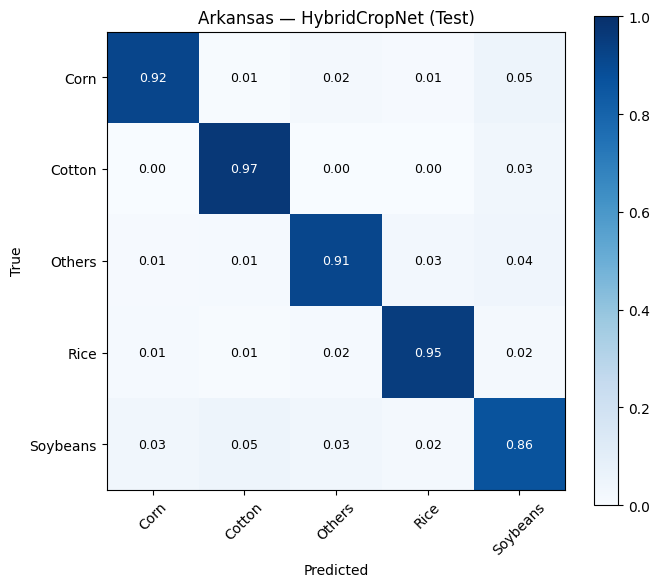


HybridCropNet — California
Classes : ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']

Construction inputs S2 + NDVI + NDWI + SAVI + GNDVI ...
Shapes : (1440, 36, 14) (360, 36, 14) (8200, 36, 14) (10000, 36, 14)

Diagnostic finitude :
  [OK] X_tr : finite, shape=(1440, 36, 14), min=-7.405, max=10.000
  [OK] X_va : finite, shape=(360, 36, 14), min=-7.405, max=10.000
  [OK] X_te : finite, shape=(8200, 36, 14), min=-7.405, max=10.000
  [OK] X_full : finite, shape=(10000, 36, 14), min=-7.405, max=10.000

Construction covariables (climat + topo + GPS) ...
Covariables : ['temp_mean_c', 'precip_mm', 'dewpoint_c', 'elevation_m', 'landform_class', 'lon', 'lat']
Shape covariables : (1440, 7)
  [OK] C_tr : finite, shape=(1440, 7), min=-4.470, max=7.971
  [OK] C_va : finite, shape=(360, 7), min=-3.850, max=5.445
  [OK] C_te : finite, shape=(8200, 7), min=-5.024, max=7.993

SSL pool size : 10000 (vs 1440 train supervisé)
Class weights : {'Alfalfa': np.float64(1.0), 'Almonds': np.fl

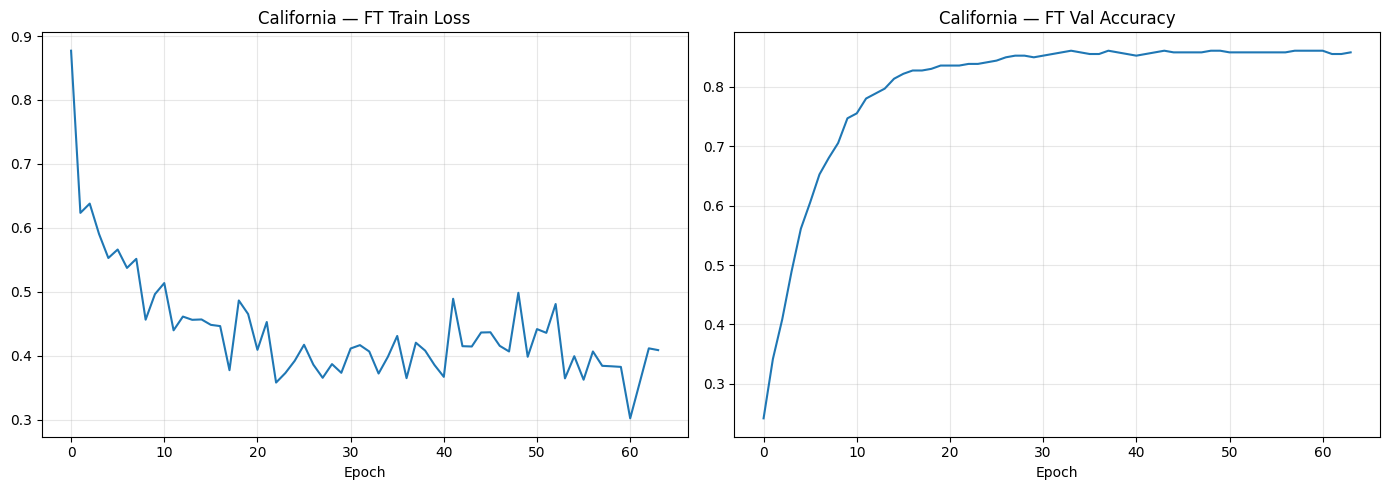


===== California — HybridCropNet (Test) =====
OA    : 0.8572
F1    : 0.7931
Kappa : 0.8126
              precision    recall  f1-score   support

     Alfalfa     0.7850    0.7908    0.7879       674
     Almonds     0.4464    0.7495    0.5595       483
      Grapes     0.8714    0.8033    0.8360      1754
      Others     0.9590    0.8518    0.9022      3212
  Pistachios     0.5698    0.8882    0.6943       340
        Rice     0.9865    0.9712    0.9788      1737

    accuracy                         0.8572      8200
   macro avg     0.7697    0.8425    0.7931      8200
weighted avg     0.8855    0.8572    0.8661      8200



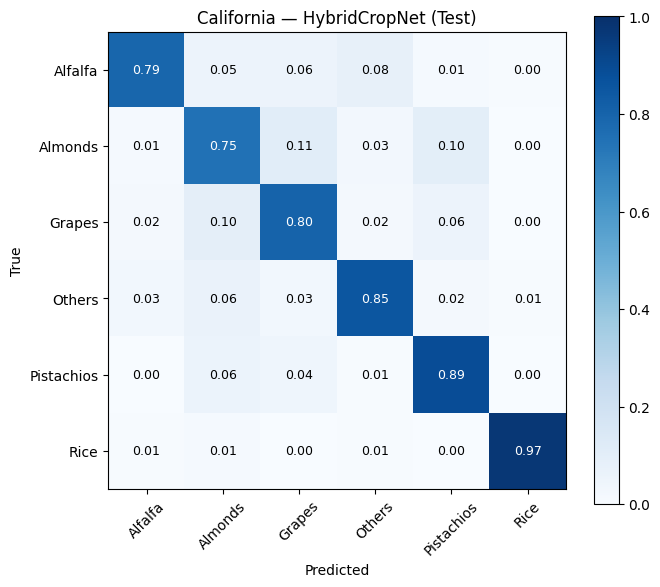


COMPARAISON PARTIE 2 vs PARTIE 3 v4.1 (HybridCropNet)
    Région                Modèle     OA     F1  Kappa
  Arkansas             MCTNet P2 0.8629 0.8112 0.7997
  Arkansas HybridCropNet P3 v4.1 0.9000 0.8499 0.8512
California             MCTNet P2 0.8484 0.7787 0.8010
California HybridCropNet P3 v4.1 0.8572 0.7931 0.8126

Sauvegardé : partie3_v4_1_results.csv


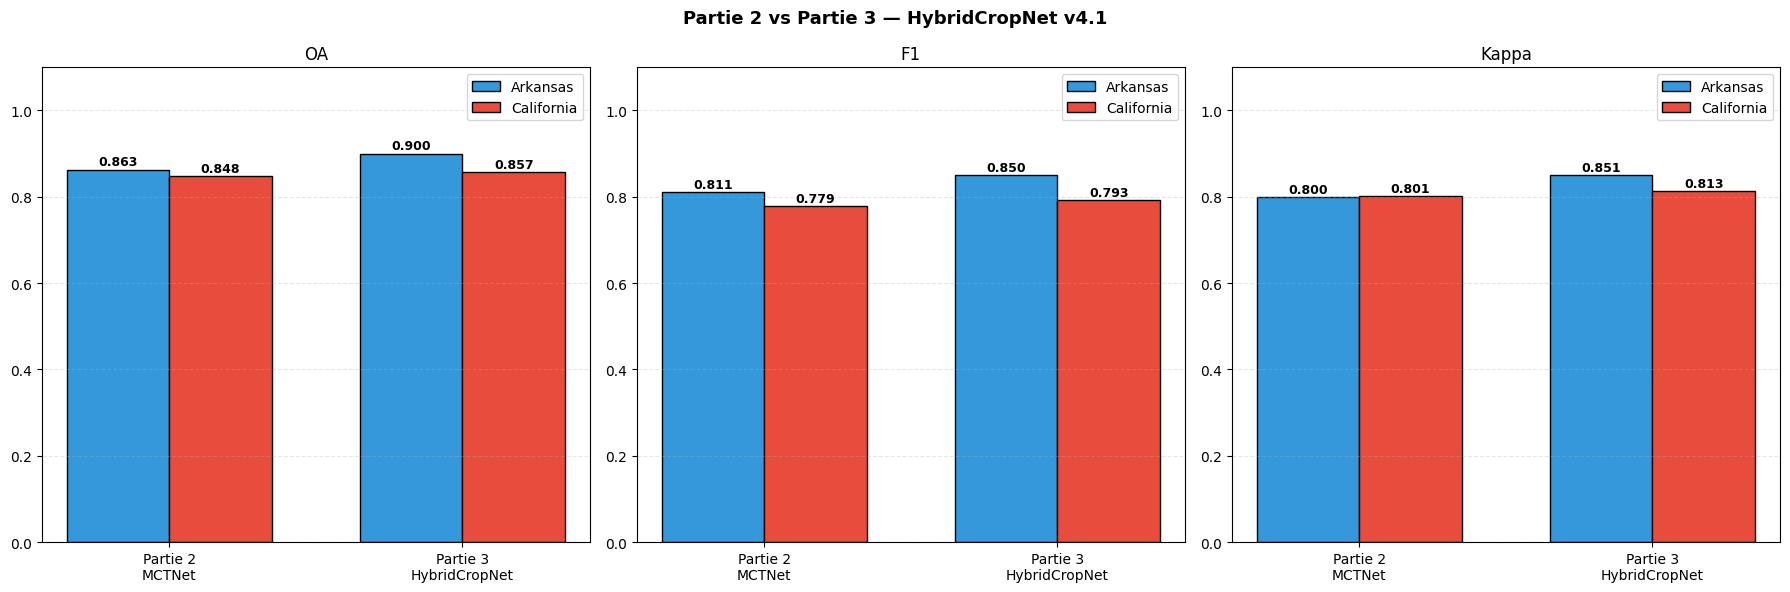

Graphique sauvegardé : partie3_v4_1_graph.png


In [ ]:
# ============================================================
# PARTIE 3 HybridCropNet
# ============================================================
# ============================================================

import copy
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score,
                             cohen_kappa_score, confusion_matrix,
                             classification_report)

# ============================================================
# REPRODUCTIBILITÉ
# ============================================================
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

BANDS      = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]
N_TIMES    = 36
EPOCHS_SSL = 80
EPOCHS_FT  = 200
PATIENCE   = 30
BATCH      = 32
LR_SSL     = 5e-4   # un peu réduit pour stabilité
LR_FT      = 5e-4

# ============================================================
# CHARGEMENT
# ============================================================
df_ark = pd.read_csv("ARKANSAS_FULL_GPS.csv").copy()
df_cal = pd.read_csv("CALIFORNIA_FULL_GPS.csv").copy()

ark_mapping = {1:"Corn", 2:"Cotton", 3:"Rice", 5:"Soybeans", 999:"Others"}
cal_mapping = {3:"Rice", 36:"Alfalfa", 69:"Grapes",
               75:"Almonds", 204:"Pistachios", 999:"Others"}

df_ark["class_name"] = df_ark["label"].map(ark_mapping).fillna("Others")
df_cal["class_name"] = df_cal["label"].map(cal_mapping).fillna("Others")

# ============================================================
# ============================================================
def sanitize_df(df, exclude=("label", "class_name")):
    df = df.copy()
    n_nan_before = 0
    n_inf_before = 0
    for col in df.columns:
        if col in exclude:
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        n_nan_before += s.isna().sum()
        n_inf_before += np.isinf(s.fillna(0)).sum()
        s = s.replace([np.inf, -np.inf], np.nan).fillna(0)
        df[col] = s.astype(np.float32)
    print(f"  NaN remplacés : {n_nan_before:,} | Inf remplacés : {n_inf_before:,}")
    return df

print("\nSanitisation Arkansas :")
df_ark = sanitize_df(df_ark)
print("Sanitisation California :")
df_cal = sanitize_df(df_cal)

# ============================================================
# INDICES VÉGÉTATION : NDVI + NDWI + SAVI + GNDVI
# ============================================================
def add_vegetation_indices(df, n_times=36):
    df  = df.copy()
    eps = 1e-6
    L   = 0.5
    new = {}
    for t in range(n_times):
        b3 = df[f"B3_t{t}"].astype(np.float32)
        b4 = df[f"B4_t{t}"].astype(np.float32)
        b8 = df[f"B8_t{t}"].astype(np.float32)
        new[f"NDVI_t{t}"]  = (b8 - b4) / (b8 + b4 + eps)
        new[f"NDWI_t{t}"]  = (b3 - b8) / (b3 + b8 + eps)
        new[f"SAVI_t{t}"]  = ((b8 - b4) / (b8 + b4 + L + eps)) * (1 + L)
        new[f"GNDVI_t{t}"] = (b8 - b3) / (b8 + b3 + eps)
    df = pd.concat([df, pd.DataFrame(new, index=df.index)], axis=1)
    # Filet de sécurité après division
    return df.replace([np.inf, -np.inf], np.nan).fillna(0)

df_ark_full = add_vegetation_indices(df_ark)
df_cal_full = add_vegetation_indices(df_cal)
print("\nAprès indices :", df_ark_full.shape, df_cal_full.shape)

# ============================================================
# SPLIT
# ============================================================
def make_split(df, n_per_class=300, train_ratio=0.8):
    train_parts, val_parts, used = [], [], []
    for cls in sorted(df["class_name"].unique()):
        df_cls = df[df["class_name"]==cls].sample(frac=1, random_state=SEED)
        n  = min(len(df_cls), n_per_class)
        nt = int(n * train_ratio)
        samp = df_cls.iloc[:n]
        train_parts.append(samp.iloc[:nt])
        val_parts.append(samp.iloc[nt:])
        used.extend(samp.index.tolist())
    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df   = pd.concat(val_parts).reset_index(drop=True)
    test_df  = df.drop(index=used).reset_index(drop=True)
    return train_df, val_df, test_df

train_ark_p3, val_ark_p3, test_ark_p3 = make_split(df_ark_full)
train_cal_p3, val_cal_p3, test_cal_p3 = make_split(df_cal_full)

# ============================================================
# UTILS
# ============================================================
def encode_labels(tr, va, te):
    le = LabelEncoder()
    return (le.fit_transform(tr["class_name"]),
            le.transform(va["class_name"]),
            le.transform(te["class_name"]), le)

# ============================================================
# build_inputs
# Construit les features [N, 36, 14] avec gestion explicite des NaN/Inf
# ============================================================
def build_inputs(df, bands=BANDS, n_times=N_TIMES):
    all_feat  = bands + ["NDVI", "NDWI", "SAVI", "GNDVI"]
    n_feat    = len(all_feat)

    # On utilise une approche vectorisée + sanitize après coup
    X = np.zeros((len(df), n_times, n_feat), dtype=np.float32)
    M = np.zeros((len(df), n_times),         dtype=np.float32)

    df = df.reset_index(drop=True)
    for f_idx, b in enumerate(all_feat):
        for t in range(n_times):
            col = f"{b}_t{t}"
            if col in df.columns:
                X[:, t, f_idx] = pd.to_numeric(
                    df[col], errors="coerce"
                ).fillna(0).astype(np.float32).values

    # Mask : un time-step est "valide" si AU MOINS UN canal est non-nul
    # (et finite). On vérifie la finitude pour ne pas marquer un NaN comme valide.
    finite_X = np.isfinite(X)
    M = (finite_X & (X != 0)).any(axis=2).astype(np.float32)

    # Filet de sécurité final
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, M

# ============================================================
# >>> FIX 3 — normalize_features avec clipping <<<
# ============================================================
def normalize_features(X_train, X_val, X_test, mask_train, X_extra=None):
    valid  = mask_train.astype(bool)
    n_chan = X_train.shape[2]
    mean   = np.zeros(n_chan, dtype=np.float32)
    std    = np.ones(n_chan,  dtype=np.float32)
    for c in range(n_chan):
        flat = X_train[..., c][valid]
        flat = flat[np.isfinite(flat)]   # extra safety
        if flat.size > 0:
            mean[c] = float(np.mean(flat))
            s       = float(np.std(flat))
            std[c]  = max(s, 1e-6)
    out = [X_train, X_val, X_test]
    if X_extra is not None:
        out.append(X_extra)
    out = [(a - mean) / std for a in out]
    # Clipping pour borner les valeurs extrêmes après normalisation
    out = [np.clip(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0),
                   -10.0, 10.0).astype(np.float32) for a in out]
    return out

def build_static_features(train_df, val_df, test_df, full_df=None):
    wanted = ["temp_mean_c", "precip_mm", "dewpoint_c",
              "elevation_m", "landform_class", "lon", "lat"]
    cov_cols = [c for c in wanted if c in train_df.columns]
    print("Covariables :", cov_cols)
    def _clean(df):
        return df[cov_cols].apply(
            pd.to_numeric, errors="coerce"
        ).replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
    scaler = StandardScaler()
    C_tr = scaler.fit_transform(_clean(train_df))
    C_va = scaler.transform(_clean(val_df))
    C_te = scaler.transform(_clean(test_df))
    out  = [C_tr, C_va, C_te]
    if full_df is not None:
        out.append(scaler.transform(_clean(full_df)))
    out  = [np.clip(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0),
                    -10.0, 10.0).astype(np.float32) for a in out]
    return out, cov_cols

# ============================================================
#  Diagnostic NaN avant entraînement
# ============================================================
def assert_clean(name, *arrays):
    for a in arrays:
        if not np.all(np.isfinite(a)):
            n_bad = (~np.isfinite(a)).sum()
            raise ValueError(f"{name} contient {n_bad} valeurs non-finies !")
    print(f"  [OK] {name} : finite, "
          f"shape={arrays[0].shape}, "
          f"min={arrays[0].min():.3f}, max={arrays[0].max():.3f}")

# ============================================================
# DATASETS
# ============================================================
class CropDS(Dataset):
    def __init__(self, X, M, C, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.M = torch.tensor(M, dtype=torch.float32)
        self.C = torch.tensor(C, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.M[i], self.C[i], self.y[i]

class SSLDS(Dataset):
    def __init__(self, X, M):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.M = torch.tensor(M, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.M[i]

# ============================================================
# ============================================================
def sinusoidal_pe(seq_len, dim, device):
    pe  = torch.zeros(seq_len, dim, device=device)
    pos = torch.arange(0, seq_len, dtype=torch.float32, device=device).unsqueeze(1)
    div = torch.exp(
        torch.arange(0, dim, 2, dtype=torch.float32, device=device)
        * (-math.log(10000.0) / dim)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

class SEBlock(nn.Module):
    def __init__(self, channels, r=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // r, 4)), nn.GELU(),
            nn.Linear(max(channels // r, 4), channels), nn.Sigmoid()
        )
    def forward(self, x):
        s = x.mean(dim=1)
        s = self.fc(s).unsqueeze(1)
        return x * s

class MultiScaleConv(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        per = out_dim // 3
        rem = out_dim - per * 3
        self.conv3 = nn.Conv1d(in_dim, per,       3, padding=1)
        self.conv5 = nn.Conv1d(in_dim, per,       5, padding=2)
        self.conv7 = nn.Conv1d(in_dim, per + rem, 7, padding=3)
        self.bn   = nn.BatchNorm1d(out_dim)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.se   = SEBlock(out_dim)
    def forward(self, x):
        z = x.transpose(1, 2)
        z = torch.cat([self.conv3(z), self.conv5(z), self.conv7(z)], dim=1)
        z = self.act(self.bn(z))
        z = z.transpose(1, 2)
        z = self.se(z)
        return self.drop(z)

class ALPEModule(nn.Module):
    def __init__(self, d_model, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size // 2)
        self.eca  = nn.Conv1d(1, 1, 3, padding=1, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x, time_mask):
        B, T, C = x.shape
        pe     = sinusoidal_pe(T, C, x.device).unsqueeze(0).expand(B, -1, -1)
        masked = pe * time_mask.unsqueeze(-1)
        z = masked.transpose(1, 2)
        z = self.conv(z)
        y = z.mean(dim=2, keepdim=True).transpose(1, 2)
        y = self.eca(y)
        y = self.sig(y).transpose(1, 2)
        return (z * y).transpose(1, 2)

class StochasticDepth(nn.Module):
    def __init__(self, p=0.1):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training or self.p == 0:
            return x
        keep = 1 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        rand  = keep + torch.rand(shape, device=x.device, dtype=x.dtype)
        rand.floor_()
        return x.div(keep) * rand

class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead=4, dropout=0.1, drop_path=0.1, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        self.alpe  = ALPEModule(d_model) if use_alpe else None
        self.attn  = nn.MultiheadAttention(d_model, nhead,
                                            dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        self.drop = nn.Dropout(dropout)
        self.dp   = StochasticDepth(drop_path)
    def forward(self, x, time_mask):
        if self.use_alpe:
            x = x + self.alpe(x, time_mask)
        else:
            pe = sinusoidal_pe(x.size(1), x.size(2), x.device)
            x  = x + pe.unsqueeze(0)
        # Sécurité : si TOUS les time-steps sont masqués pour une ligne,
        # on remet au moins le premier à 1 pour éviter NaN dans l'attention
        kpm        = (time_mask == 0)
        all_masked = kpm.all(dim=1)
        if all_masked.any():
            kpm = kpm.clone()
            kpm[all_masked, 0] = False
        a, _ = self.attn(x, x, x, key_padding_mask=kpm)
        x    = self.norm1(x + self.dp(self.drop(a)))
        x    = self.norm2(x + self.dp(self.drop(self.ffn(x))))
        return x

class BiGRUBlock(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.gru  = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.norm(x + self.drop(out))

class CrossAttentionFusion(nn.Module):
    def __init__(self, d_model, n_cov, nhead=4, dropout=0.1):
        super().__init__()
        self.cov_proj = nn.Sequential(
            nn.Linear(n_cov, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model)
        )
        self.cross_attn = nn.MultiheadAttention(d_model, nhead,
                                                dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model * 2, d_model), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model)
        )
        self.drop = nn.Dropout(dropout)
    def forward(self, temporal_feats, time_mask, static_feats):
        cov_emb = self.cov_proj(static_feats).unsqueeze(1)
        kpm     = (time_mask == 0)
        all_masked = kpm.all(dim=1)
        if all_masked.any():
            kpm = kpm.clone()
            kpm[all_masked, 0] = False
        att, _  = self.cross_attn(cov_emb, temporal_feats, temporal_feats,
                                  key_padding_mask=kpm)
        cov_ctx  = self.norm1(cov_emb + self.drop(att)).squeeze(1)
        # Pooling masqué : on remplace les positions invalides par -inf,
        # puis on prend max. S'il n'y a aucune position valide, on prend 0.
        valid_any = time_mask.sum(dim=1, keepdim=True) > 0           # [B, 1]
        t_masked  = temporal_feats.masked_fill(
            time_mask.unsqueeze(-1) == 0, float('-inf')
        )
        t_pool   = t_masked.max(dim=1).values                        # [B, d]
        t_pool   = torch.where(
            valid_any, t_pool, torch.zeros_like(t_pool)
        )
        fused    = self.ffn(torch.cat([t_pool, cov_ctx], dim=1))
        return self.norm2(t_pool + self.drop(fused))

# ============================================================
# MODÈLE PRINCIPAL
# ============================================================
class HybridCropNet(nn.Module):
    def __init__(self, input_dim=14, n_cov=7, num_classes=5,
                 d_model=128, n_heads=4, n_blocks=2,
                 dropout=0.2, drop_path=0.1):
        super().__init__()
        self.frontend = MultiScaleConv(input_dim, d_model, dropout)
        self.blocks = nn.ModuleList()
        for i in range(n_blocks):
            self.blocks.append(nn.ModuleDict({
                "trans": TransformerBlock(d_model, n_heads, dropout,
                                          drop_path, use_alpe=(i == 0)),
                "gru":   BiGRUBlock(d_model, dropout)
            }))
        self.fusion = CrossAttentionFusion(d_model, n_cov, n_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )
        self.reconstructor = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, input_dim)
        )

    def encode(self, x, time_mask):
        h = self.frontend(x)
        for blk in self.blocks:
            h = blk["trans"](h, time_mask)
            h = blk["gru"](h)
        return h

    def reconstruct(self, x, time_mask):
        h = self.encode(x, time_mask)
        return self.reconstructor(h)

    def forward(self, x, time_mask, x_cov):
        h    = self.encode(x, time_mask)
        feat = self.fusion(h, time_mask, x_cov)
        return self.classifier(feat)

# ============================================================
# UTILITAIRES D'ENTRAÎNEMENT
# ============================================================
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()
                       if v.dtype.is_floating_point}
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(),
                                                     alpha=1 - self.decay)
    def apply_to(self, model):
        backup = {k: v.detach().clone() for k, v in model.state_dict().items()
                  if k in self.shadow}
        for k, v in model.state_dict().items():
            if k in self.shadow:
                v.copy_(self.shadow[k])
        return backup
    def restore(self, model, backup):
        for k, v in model.state_dict().items():
            if k in backup:
                v.copy_(backup[k])

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=1.5, smoothing=0.05):
        super().__init__()
        self.weight    = weight
        self.gamma     = gamma
        self.smoothing = smoothing
    def forward(self, logits, target):
        n_class = logits.size(1)
        with torch.no_grad():
            one_hot = torch.zeros_like(logits).fill_(self.smoothing /
                                                     max(n_class - 1, 1))
            one_hot.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        log_prob = F.log_softmax(logits, dim=1)
        prob     = log_prob.exp()
        focal    = (1.0 - prob) ** self.gamma
        loss     = -(one_hot * focal * log_prob)
        if self.weight is not None:
            loss = loss * self.weight.to(logits.device).unsqueeze(0)
        return loss.sum(dim=1).mean()

def mixup(x, m, c, y, alpha=0.2):
    if alpha <= 0:
        return x, m, c, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    c_mix = lam * c + (1 - lam) * c[idx]
    m_mix = torch.maximum(m, m[idx])
    return x_mix, m_mix, c_mix, y, y[idx], lam

def mixup_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

# ============================================================
#  SSL avec gestion NaN <<<
# ============================================================
def pretrain_ssl(model, ssl_loader, device, epochs=80,
                 lr=5e-4, mask_ratio=0.4):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4, eps=1e-7)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse       = nn.MSELoss(reduction='none')

    print(f"\n>>> SSL Pretraining ({epochs} epochs, mask_ratio={mask_ratio})")
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0; n_batches = 0; n_skipped = 0

        for X, M in ssl_loader:
            X, M = X.to(device), M.to(device)
            B, T, _ = X.shape

            rand           = torch.rand(B, T, device=device)
            mask_for_recon = (rand < mask_ratio) & M.bool()

            # Si aucun batch ne contient de positions à reconstruire, skip
            if mask_for_recon.sum() == 0:
                continue

            X_in = X.clone()
            M_in = M.clone()
            X_in[mask_for_recon] = 0
            M_in[mask_for_recon] = 0

            optimizer.zero_grad()
            recon = model.reconstruct(X_in, M_in)

            per_step = mse(recon, X).mean(dim=2)
            mask_f   = mask_for_recon.float()
            loss     = (per_step * mask_f).sum() / (mask_f.sum() + 1e-6)

            # Sécurité : on saute le batch si NaN/Inf
            if not torch.isfinite(loss):
                n_skipped += 1
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches  += 1

        scheduler.step()
        if (epoch + 1) % 10 == 0 or epoch == 0:
            avg = total_loss / max(1, n_batches)
            extra = f" | skipped={n_skipped}" if n_skipped else ""
            print(f"  SSL epoch {epoch+1:03d}/{epochs} | "
                  f"recon_loss={avg:.4f}{extra}")
    print("  SSL pretraining done.")
    return model

# ============================================================
# FINE-TUNING (avec safeguard NaN)
# ============================================================
def finetune(model, tr_ldr, va_ldr, device, class_weights,
             epochs=200, lr=5e-4, mixup_alpha=0.2, patience=30):

    criterion = FocalLoss(weight=class_weights, gamma=1.5, smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4, eps=1e-7)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=40, T_mult=2
    )
    ema = EMA(model, decay=0.999)

    best_val = 0.0; best_state = None; no_improve = 0
    history  = {"loss": [], "val_acc": []}

    print(f"\n>>> Fine-tuning ({epochs} epochs max, patience={patience})")
    for epoch in range(epochs):
        model.train()
        ep_loss = 0.0; nb = 0
        for X, M, C, y in tr_ldr:
            X, M, C, y = X.to(device), M.to(device), C.to(device), y.to(device)
            X_m, M_m, C_m, y_a, y_b, lam = mixup(X, M, C, y, mixup_alpha)

            optimizer.zero_grad()
            logits = model(X_m, M_m, C_m)
            loss   = mixup_loss(criterion, logits, y_a, y_b, lam)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ema.update(model)
            ep_loss += loss.item(); nb += 1
        scheduler.step()
        ep_loss /= max(1, nb)

        backup = ema.apply_to(model)
        model.eval()
        yt, yp = [], []
        with torch.no_grad():
            for X, M, C, y in va_ldr:
                pred = torch.argmax(
                    model(X.to(device), M.to(device), C.to(device)), dim=1
                )
                yt.extend(y.numpy()); yp.extend(pred.cpu().numpy())
        val_acc = accuracy_score(yt, yp)

        history["loss"].append(ep_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val + 1e-4:
            best_val   = val_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        ema.restore(model, backup)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  FT epoch {epoch+1:03d}/{epochs} | "
                  f"loss={ep_loss:.4f} | val={val_acc:.4f} | best={best_val:.4f}")

        if no_improve >= patience:
            print(f"  Early stopping à l'époque {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  Meilleure val_acc : {best_val:.4f}")
    return model, history

# ============================================================
# ÉVALUATION
# ============================================================
def evaluate_full(model, loader, device, le, title=""):
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for X, M, C, y in loader:
            pred = torch.argmax(
                model(X.to(device), M.to(device), C.to(device)), dim=1
            )
            yt.extend(y.numpy()); yp.extend(pred.cpu().numpy())

    yt, yp = np.array(yt), np.array(yp)
    oa = accuracy_score(yt, yp)
    f1 = f1_score(yt, yp, average="macro")
    kp = cohen_kappa_score(yt, yp)
    cm = confusion_matrix(yt, yp, normalize="true")

    print(f"\n===== {title} =====")
    print(f"OA    : {oa:.4f}")
    print(f"F1    : {f1:.4f}")
    print(f"Kappa : {kp:.4f}")
    print(classification_report(yt, yp, target_names=le.classes_, digits=4))

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ticks = np.arange(len(le.classes_))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(le.classes_, rotation=45)
    ax.set_yticklabels(le.classes_)
    plt.colorbar(im, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                    color="white" if cm[i,j] > 0.5 else "black", fontsize=9)
    plt.tight_layout(); plt.show()
    return oa, f1, kp

# ============================================================
# PIPELINE COMPLET PAR RÉGION
# ============================================================
def run_hybrid_pipeline(df_full, train_df, val_df, test_df, region):
    print(f"\n{'='*60}")
    print(f"HybridCropNet — {region}")
    print(f"{'='*60}")

    y_tr, y_va, y_te, le = encode_labels(train_df, val_df, test_df)
    print("Classes :", list(le.classes_))

    print("\nConstruction inputs S2 + NDVI + NDWI + SAVI + GNDVI ...")
    X_tr, M_tr     = build_inputs(train_df)
    X_va, M_va     = build_inputs(val_df)
    X_te, M_te     = build_inputs(test_df)
    X_full, M_full = build_inputs(df_full)
    print("Shapes :", X_tr.shape, X_va.shape, X_te.shape, X_full.shape)

    X_tr, X_va, X_te, X_full = normalize_features(
        X_tr, X_va, X_te, M_tr, X_extra=X_full
    )

    print("\nDiagnostic finitude :")
    assert_clean("X_tr", X_tr)
    assert_clean("X_va", X_va)
    assert_clean("X_te", X_te)
    assert_clean("X_full", X_full)

    print("\nConstruction covariables (climat + topo + GPS) ...")
    (C_tr, C_va, C_te, _C_full), cov_cols = build_static_features(
        train_df, val_df, test_df, full_df=df_full
    )
    n_cov = C_tr.shape[1]
    print("Shape covariables :", C_tr.shape)
    assert_clean("C_tr", C_tr)
    assert_clean("C_va", C_va)
    assert_clean("C_te", C_te)

    tr_ds = CropDS(X_tr, M_tr, C_tr, y_tr)
    va_ds = CropDS(X_va, M_va, C_va, y_va)
    te_ds = CropDS(X_te, M_te, C_te, y_te)
    tr_ldr = DataLoader(tr_ds, BATCH, shuffle=True)
    va_ldr = DataLoader(va_ds, BATCH, shuffle=False)
    te_ldr = DataLoader(te_ds, BATCH, shuffle=False)

    ssl_ds  = SSLDS(X_full, M_full)
    ssl_ldr = DataLoader(ssl_ds, batch_size=64, shuffle=True)
    print(f"\nSSL pool size : {len(ssl_ds)} (vs {len(tr_ds)} train supervisé)")

    classes = np.unique(y_tr)
    w = compute_class_weight("balanced", classes=classes, y=y_tr)
    class_weights = torch.tensor(w, dtype=torch.float32)
    print("Class weights :", dict(zip(le.classes_, np.round(w, 3))))

    model = HybridCropNet(
        input_dim=14, n_cov=n_cov, num_classes=len(le.classes_),
        d_model=128, n_heads=4, n_blocks=2, dropout=0.2, drop_path=0.1
    ).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Paramètres : {n_params:,}")

    model = pretrain_ssl(model, ssl_ldr, DEVICE,
                         epochs=EPOCHS_SSL, lr=LR_SSL, mask_ratio=0.4)

    model, hist = finetune(
        model, tr_ldr, va_ldr, DEVICE,
        class_weights=class_weights,
        epochs=EPOCHS_FT, lr=LR_FT,
        mixup_alpha=0.2, patience=PATIENCE
    )

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    a1.plot(hist["loss"]);    a1.set_title(f"{region} — FT Train Loss")
    a1.set_xlabel("Epoch");   a1.grid(True, alpha=0.3)
    a2.plot(hist["val_acc"]); a2.set_title(f"{region} — FT Val Accuracy")
    a2.set_xlabel("Epoch");   a2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    oa, f1, kp = evaluate_full(
        model, te_ldr, DEVICE, le,
        title=f"{region} — HybridCropNet (Test)"
    )
    return {"OA": round(oa, 4), "F1": round(f1, 4), "Kappa": round(kp, 4)}

# ============================================================
# LANCEMENT
# ============================================================
p2_ark = results_ark["S2 + All"]
p2_cal = results_cal["S2 + All"]

results_ark_p3 = run_hybrid_pipeline(
    df_ark_full, train_ark_p3, val_ark_p3, test_ark_p3, "Arkansas"
)
results_cal_p3 = run_hybrid_pipeline(
    df_cal_full, train_cal_p3, val_cal_p3, test_cal_p3, "California"
)

# ============================================================
# TABLEAU + GRAPHIQUE COMPARATIF
# ============================================================
print("\n" + "=" * 70)
print("COMPARAISON PARTIE 2 vs PARTIE 3 v4.1 (HybridCropNet)")
print("=" * 70)

df_compare = pd.DataFrame({
    "Région" : ["Arkansas", "Arkansas", "California", "California"],
    "Modèle" : ["MCTNet P2", "HybridCropNet P3 v4.1",
                "MCTNet P2", "HybridCropNet P3 v4.1"],
    "OA"     : [p2_ark["OA"],    results_ark_p3["OA"],
                p2_cal["OA"],    results_cal_p3["OA"]],
    "F1"     : [p2_ark["F1"],    results_ark_p3["F1"],
                p2_cal["F1"],    results_cal_p3["F1"]],
    "Kappa"  : [p2_ark["Kappa"], results_ark_p3["Kappa"],
                p2_cal["Kappa"], results_cal_p3["Kappa"]],
})
print(df_compare.to_string(index=False))
df_compare.to_csv("partie3_v4_1_results.csv", index=False)
print("\nSauvegardé : partie3_v4_1_results.csv")

metrics = ["OA", "F1", "Kappa"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, m in zip(axes, metrics):
    x = np.arange(2); w = 0.35
    b1 = ax.bar(x - w/2, [p2_ark[m], results_ark_p3[m]], w,
                label="Arkansas", color="#3498db", edgecolor="black")
    b2 = ax.bar(x + w/2, [p2_cal[m], results_cal_p3[m]], w,
                label="California", color="#e74c3c", edgecolor="black")
    ax.set_title(m); ax.set_xticks(x)
    ax.set_xticklabels(["Partie 2\nMCTNet", "Partie 3\nHybridCropNet"])
    ax.set_ylim(0, 1.1); ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold")
plt.suptitle("Partie 2 vs Partie 3 — HybridCropNet v4.1",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("partie3_v4_1_graph.png", dpi=300, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : partie3_v4_1_graph.png")
